# Can Instamart Catch Blinkit?
### A unit-economics teardown of India's quick-commerce race (Blinkit vs Swiggy Instamart vs Zepto), Q4FY24 – Q1FY27

**Author:** Harshvardhan · **Data as of:** Q1FY27 results (quarter ending 30 Jun 2026) · **Data:** company shareholder letters + Zepto's UDRHP (12 quarters of KPIs) (all sources cited in `data/`)

**The brief (framed as a real stakeholder ask):**
> *"You're a strategy analyst on Swiggy Instamart's finance & strategy team. Instamart just hit contribution-margin break-even, but Blinkit is profitable at the EBITDA level and pulling away. Tell leadership **why the gap exists, what it would take to close it, and which levers to pull first.**"*

---
## Executive summary

1. **Blinkit is pulling away.** Its share of combined Blinkit + Instamart NOV (net order value) rose from **63% → 75%** in two years (Q1FY25 → Q1FY27). Blinkit grew NOV **4.2×**; Instamart **2.4×**.
2. **The gap is not per-order margin, it's store throughput.** Both earn similar basket sizes (~₹510–520 net AOV), but a Blinkit store does **~₹8.0 lakh NOV/day vs ~₹5.5 lakh** at Instamart (+45%). Instamart carries **~₹72k of below-contribution fixed cost per store-day vs ~₹38k** at Blinkit — the same costs spread over far less volume.
3. **The throughput gap is a *frequency* gap.** Blinkit users order **~3.5×/month**, flat for a year. Instamart's frequency fell from **3.6 → 2.8** as it deliberately weaned off ~4M unprofitable users. Blinkit's last-12-month growth came almost entirely from new users (+88% MTU).
4. **Break-even math checks out, but it's a long road.** My model independently reproduces management's guidance: at a 5.5% contribution margin, Instamart needs **~₹55–64k Cr annualised NOV** (≈2.6× today's run-rate), bracketing management's own ₹60k Cr guidance — i.e. it has to become roughly as big as Blinkit is *today*.
5. **Zepto shows throughput alone isn't enough.** Its stores are the busiest (~2,140 orders/day in Q4FY26), yet a ~₹387 basket and heavy variable spend kept it at **−₹59 per order**. FY26 Adj. EBITDA per order: Zepto **−₹79**, Instamart **−₹85**, Blinkit **−₹3**.

**Recommendation:** Prioritise **densification and frequency over new stores**. With store utilisation at ~40%, each +₹1 lakh NOV/store/day on the current 1,171-store network is worth **~₹4,300 Cr of annualised NOV (~₹235 Cr EBITDA)** at near-zero incremental fixed cost. Pair it with a measured basket-building experiment (design + power analysis in §7) and the ads lever (₹10/order guided).

---
**Contents:** 1 Setup & data · 2 Market structure · 3 Growth decomposition (metric tree) · 4 Store productivity & operating leverage · 5 Unit economics per order · 6 Break-even & scenario model · 7 Experiment design · 8 Blinkit ROCE sensitivity · 9 Recommendations · 10 Limitations

## 1. Setup & data
All numbers come from public filings. Where a figure is **derived** (e.g. Instamart GOV = orders × AOV), the `notes` column says so.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mtick
from pathlib import Path
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
CHARTS = Path("charts"); CHARTS.mkdir(exist_ok=True)

# ---- one consistent, colour-blind-validated palette: colour follows the company, never rank ----
COL = {"Blinkit": "#2a78d6", "Instamart": "#eb6834", "Zepto": "#1baf7a"}
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 10.5, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "legend.frameon": False,
    "lines.linewidth": 2, "figure.dpi": 110, "axes.axisbelow": True,
})
def rs(v, dec=0):
    "Format rupees with a proper minus sign: -3 -> '−₹3'"
    return ("−" if v < 0 else "") + f"₹{abs(v):,.{dec}f}"
def save(fig, name):
    fig.tight_layout(); fig.savefig(CHARTS / f"{name}.png", dpi=160, bbox_inches="tight")

panel = pd.read_csv("data/qcom_quarterly_panel.csv", parse_dates=["period_end"])
zepto = pd.read_csv("data/zepto_annual.csv")
guide = pd.read_csv("data/management_guidance.csv")
G = guide.set_index(["platform", "metric"]).value
Q = ["Q4FY24","Q1FY25","Q2FY25","Q3FY25","Q4FY25","Q1FY26","Q2FY26","Q3FY26","Q4FY26","Q1FY27"]
panel["quarter"] = pd.Categorical(panel.quarter, Q, ordered=True)
panel = panel.sort_values(["platform", "quarter"])
panel[["platform","quarter","nov_cr","orders_mn","mtu_mn","stores_end","contribution_cr","adj_ebitda_cr"]]

,platform,quarter,nov_cr,orders_mn,mtu_mn,stores_end,contribution_cr,adj_ebitda_cr
0,Blinkit,Q4FY24,"3,336.0",NaN,NaN,526,158.0,-37
1,Blinkit,Q1FY25,"4,061.0",NaN,NaN,639,199.0,-3
2,Blinkit,Q2FY25,"4,928.0",NaN,NaN,791,234.0,-8
3,Blinkit,Q3FY25,"6,020.0",NaN,NaN,1007,232.0,-103
4,Blinkit,Q4FY25,"7,362.0",NaN,NaN,1301,289.0,-178
5,Blinkit,Q1FY26,"9,203.0",176.7,16.9,1544,360.0,-162
6,Blinkit,Q2FY26,"11,679.0",222.7,20.8,1816,542.0,-156
7,Blinkit,Q3FY26,"13,300.0",243.3,23.6,2027,736.0,4
8,Blinkit,Q4FY26,"14,386.0",273.9,27.2,2243,782.0,37
9,Blinkit,Q1FY27,"17,132.0",331.0,31.8,2443,907.0,102


In [2]:
# ---- Feature engineering: the metrics an analyst actually argues with ----
DAYS = 91  # days per quarter (approx.)
prev_stores = {"Instamart": 523}  # Q4FY24 exit stores (Swiggy Q3FY25 letter) so Q1FY25 has an opening balance

def enrich(d):
    d = d.copy()
    d["avg_stores"]         = (d.stores_end + d.stores_end.shift().fillna(prev_stores.get(d.platform.iat[0], np.nan))) / 2
    d["naov_inr"]           = d.nov_cr * 1e7 / (d.orders_mn * 1e6)                  # net AOV
    d["freq_per_month"]     = d.orders_mn / (d.mtu_mn * 3)                          # orders per MTU per month
    d["nov_store_day_lakh"] = d.nov_cr * 1e7 / (d.avg_stores * DAYS) / 1e5          # computed the same way for both
    d["cm_pct_nov"]         = d.contribution_cr / d.nov_cr * 100
    d["ebitda_pct_nov"]     = d.adj_ebitda_cr / d.nov_cr * 100
    d["cm_per_order"]       = d.contribution_cr * 1e7 / (d.orders_mn * 1e6)
    d["ebitda_per_order"]   = d.adj_ebitda_cr * 1e7 / (d.orders_mn * 1e6)
    d["fixed_cr"]           = d.contribution_cr - d.adj_ebitda_cr                   # costs below contribution
    d["fixed_store_day_k"]  = d.fixed_cr * 1e7 / (d.avg_stores * DAYS) / 1e3
    d["store_growth_qoq"]   = d.stores_end.pct_change() * 100
    return d

df = pd.concat([enrich(g) for _, g in panel.groupby("platform", observed=True)])
B, I = (df[df.platform == p].set_index("quarter") for p in ["Blinkit", "Instamart"])
df[["platform","quarter","naov_inr","freq_per_month","nov_store_day_lakh","cm_pct_nov","ebitda_pct_nov","ebitda_per_order","fixed_store_day_k"]].round(1)

,platform,quarter,naov_inr,freq_per_month,nov_store_day_lakh,cm_pct_nov,ebitda_pct_nov,ebitda_per_order,fixed_store_day_k
0,Blinkit,Q4FY24,NaN,NaN,NaN,4.7,-1.1,NaN,NaN
1,Blinkit,Q1FY25,NaN,NaN,7.7,4.9,-0.1,NaN,38.1
2,Blinkit,Q2FY25,NaN,NaN,7.6,4.7,-0.2,NaN,37.2
3,Blinkit,Q3FY25,NaN,NaN,7.4,3.9,-1.7,NaN,40.9
4,Blinkit,Q4FY25,NaN,NaN,7.0,3.9,-2.4,NaN,44.5
5,Blinkit,Q1FY26,520.8,3.5,7.1,3.9,-1.8,-9.2,40.3
6,Blinkit,Q2FY26,524.4,3.6,7.6,4.6,-1.3,-7.0,45.7
7,Blinkit,Q3FY26,546.7,3.4,7.6,5.5,0.0,0.2,41.9
8,Blinkit,Q4FY26,525.2,3.4,7.4,5.4,0.3,1.4,38.3
9,Blinkit,Q1FY27,517.6,3.5,8.0,5.3,0.6,3.1,37.8


**Sanity check on my derived metrics.** Blinkit publishes its own *NOV per day per store*; my computed version (NOV ÷ average stores ÷ 91) should track it closely. It does, within ~3–4%, the residual being Blinkit's day-weighted averaging. That gives me confidence to apply the **same formula to Instamart**, which doesn't publish this metric.

In [3]:
chk = B.loc["Q1FY26":, ["nov_per_store_day_k", "nov_store_day_lakh"]].assign(reported_lakh=lambda x: x.nov_per_store_day_k/100)
chk["diff_%"] = (chk.nov_store_day_lakh / chk.reported_lakh - 1) * 100
chk[["reported_lakh", "nov_store_day_lakh", "diff_%"]]

,reported_lakh,nov_store_day_lakh,diff_%
quarter,,,
Q1FY26,7.3,7.1,-3.1
Q2FY26,7.7,7.6,-0.9
Q3FY26,7.5,7.6,1.4
Q4FY26,7.7,7.4,-3.6
Q1FY27,8.3,8.0,-2.8


## 2. Market structure: Blinkit is pulling away

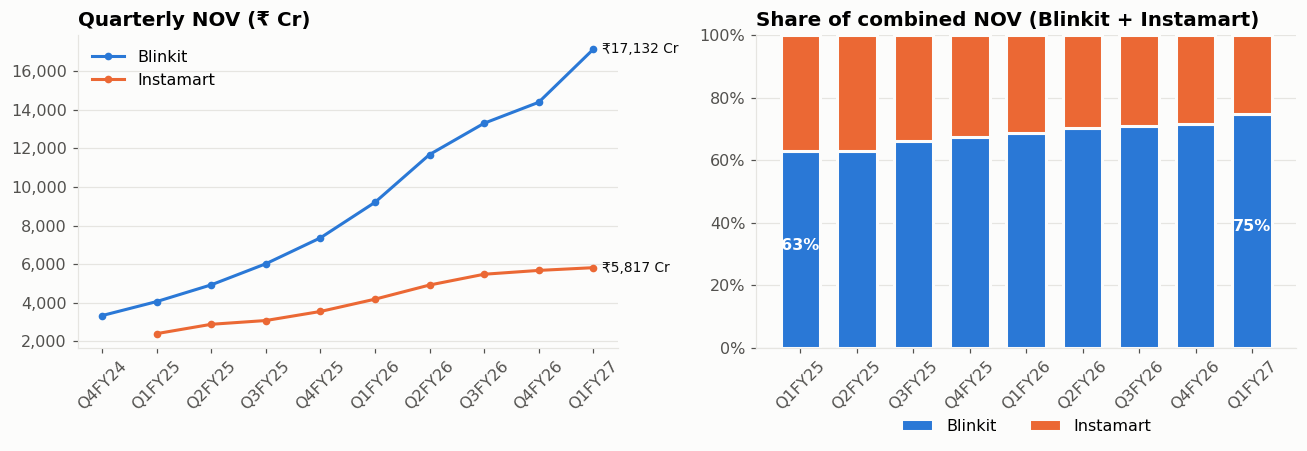

Blinkit NOV growth Q1FY25->Q1FY27: 4.2x | Instamart: 2.4x


In [4]:
share = pd.DataFrame({"Blinkit": B.nov_cr, "Instamart": I.nov_cr}).dropna()
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
for p in ["Blinkit", "Instamart"]:
    s = df[df.platform == p].set_index("quarter").nov_cr
    a1.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=p)
    a1.annotate(f"₹{s.iloc[-1]:,.0f} Cr", (str(s.index[-1]), s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=INK, fontsize=9)
a1.set_title("Quarterly NOV (₹ Cr)"); a1.legend(loc="upper left"); a1.tick_params(axis="x", rotation=45)
a1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))

x = share_pct.index.astype(str)
a2.bar(x, share_pct.Blinkit, color=COL["Blinkit"], width=0.7, label="Blinkit", edgecolor=SURF, linewidth=2)
a2.bar(x, share_pct.Instamart, bottom=share_pct.Blinkit, color=COL["Instamart"], width=0.7, label="Instamart", edgecolor=SURF, linewidth=2)
for k in [0, len(x)-1]:
    a2.text(k, share_pct.Blinkit.iloc[k]/2, f"{share_pct.Blinkit.iloc[k]:.0f}%", ha="center", color="white", fontweight="bold")
a2.set_title("Share of combined NOV (Blinkit + Instamart)"); a2.set_ylim(0, 100); a2.yaxis.set_major_formatter(mtick.PercentFormatter())
a2.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.18)); a2.tick_params(axis="x", rotation=45)
save(fig, "01_market_share"); plt.show()
print(f"Blinkit NOV growth Q1FY25->Q1FY27: {B.nov_cr['Q1FY27']/B.nov_cr['Q1FY25']:.1f}x | Instamart: {I.nov_cr['Q1FY27']/I.nov_cr['Q1FY25']:.1f}x")

**Adding Zepto (annual, FY26).** Zepto is unlisted, so the only audited view is its June-2026 UDRHP. It reports *revenue*, not NOV, so I compare on **orders** and **Adj. EBITDA per order**, the two metrics that are defined (roughly) alike across all three.

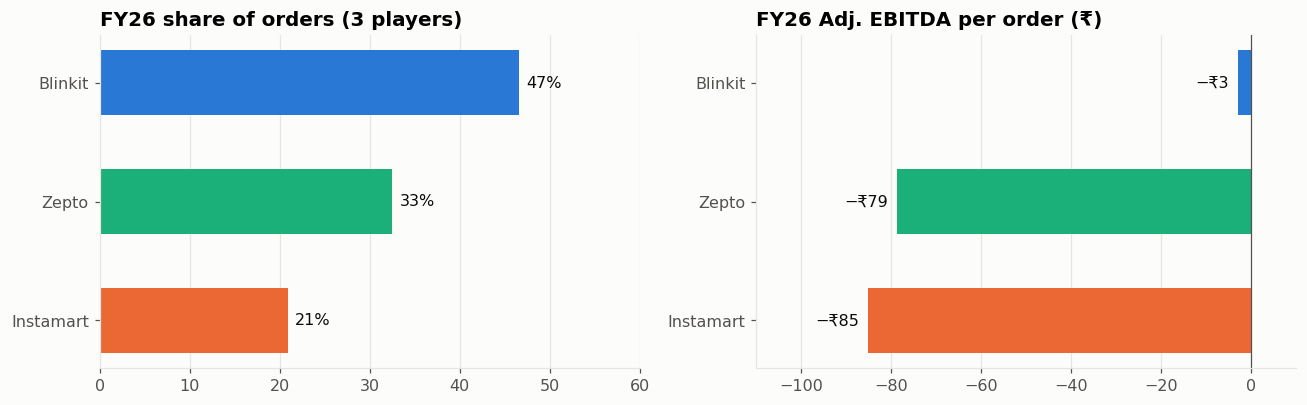

,orders_mn,adj_ebitda_cr,ebitda_per_order_inr,order_share_%
platform,,,,
Blinkit,916.6,-277.0,-3.0,46.6
Zepto,640.0,"-5,041.5",-78.8,32.5
Instamart,412.2,"-3,511.0",-85.2,20.9


In [5]:
fy26 = ["Q1FY26","Q2FY26","Q3FY26","Q4FY26"]
agg = (df[df.quarter.isin(fy26)].groupby("platform", observed=True)
         .agg(orders_mn=("orders_mn","sum"), adj_ebitda_cr=("adj_ebitda_cr","sum")))
z = zepto.set_index("fiscal_year").loc["FY26"]
agg.loc["Zepto"] = [z.orders_mn_derived, z.adj_ebitda_cr]
agg["ebitda_per_order_inr"] = agg.adj_ebitda_cr * 1e7 / (agg.orders_mn * 1e6)
agg["order_share_%"] = agg.orders_mn / agg.orders_mn.sum() * 100
agg = agg.loc[["Blinkit", "Zepto", "Instamart"]]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.barh(agg.index[::-1], agg["order_share_%"][::-1], color=[COL[p] for p in agg.index[::-1]], height=0.55)
for y, v in enumerate(agg["order_share_%"][::-1]): a1.text(v + 0.8, y, f"{v:.0f}%", va="center", color=INK)
a1.set_title("FY26 share of orders (3 players)"); a1.set_xlim(0, 60); a1.grid(axis="x"); a1.grid(axis="y", visible=False)
a2.barh(agg.index[::-1], agg.ebitda_per_order_inr[::-1], color=[COL[p] for p in agg.index[::-1]], height=0.55)
for y, v in enumerate(agg.ebitda_per_order_inr[::-1]): a2.text(v - 2, y, rs(v), va="center", ha="right", color=INK)
a2.axvline(0, color=INK2, lw=0.8); a2.set_xlim(-110, 10); a2.set_title("FY26 Adj. EBITDA per order (₹)"); a2.grid(axis="x"); a2.grid(axis="y", visible=False)
save(fig, "02_fy26_three_players"); plt.show()
agg.round(1)

> Definitions differ: Blinkit counts orders *including cancellations*; Zepto counts orders *successfully placed*. Treat shares as ±3pp directional, not precise. (Zepto's FY26 order count from its quarterly KPI table, 640M, matches the figure I had derived from its reported loss per order, a useful cross-check.)

### 2b. Zepto: the exception that sharpens the argument
Zepto's updated DRHP (SEBI, June 2026) discloses **12 quarters of KPIs**. It complicates the simple "busier stores = profit" story:

,Orders / store / day,Sales / order (₹),Sales / store / day (₹ lakh),Adj. EBITDA / order (₹)
Blinkit,"1,410.0",525.0,7.4,1.0
Instamart,"1,093.0",504.0,5.5,-76.0
Zepto,"2,140.0",387.0,8.1,-59.0


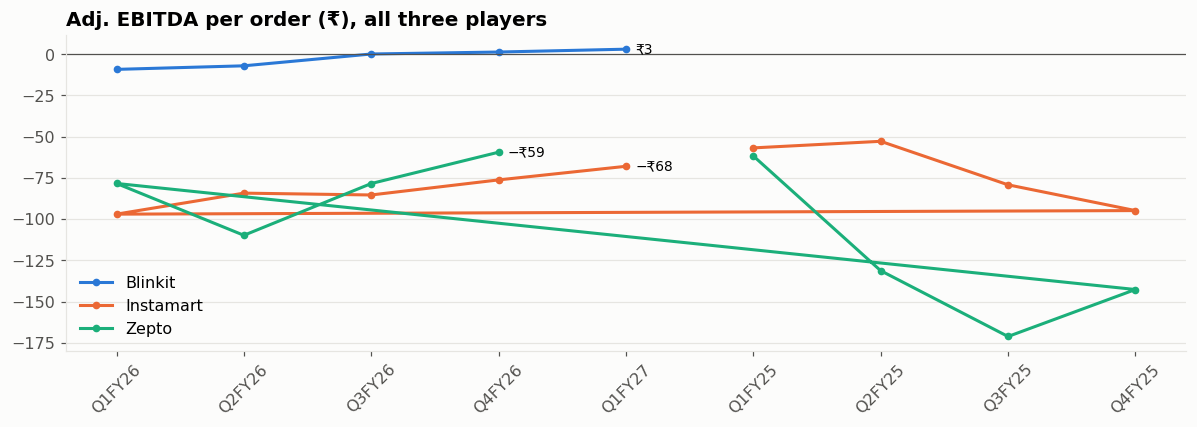

In [6]:
zq = pd.read_csv("data/zepto_quarterly.csv").set_index("quarter")
zq["avg_stores"] = (zq.stores_end + zq.stores_end.shift()) / 2
zq["nrv_per_order"] = zq.nrv_cr * 1e7 / (zq.orders_mn * 1e6)
zq["nrv_store_day_lakh"] = zq.nrv_cr * 1e7 / (zq.avg_stores * DAYS) / 1e5
cmp = pd.DataFrame({
    "Orders / store / day": [B.orders_mn["Q4FY26"]*1e6/(B.avg_stores["Q4FY26"]*DAYS), I.orders_per_store_day["Q4FY26"], zq.orders_per_store_day["Q4FY26"]],
    "Sales / order (₹)":    [B.naov_inr["Q4FY26"], I.naov_inr["Q4FY26"], zq.nrv_per_order["Q4FY26"]],
    "Sales / store / day (₹ lakh)": [B.nov_store_day_lakh["Q4FY26"], I.nov_store_day_lakh["Q4FY26"], zq.nrv_store_day_lakh["Q4FY26"]],
    "Adj. EBITDA / order (₹)": [B.ebitda_per_order["Q4FY26"], I.ebitda_per_order["Q4FY26"], zq.adj_ebitda_per_order_inr["Q4FY26"]],
}, index=["Blinkit", "Instamart", "Zepto"]).round({"Orders / store / day": 0, "Sales / order (₹)": 0, "Sales / store / day (₹ lakh)": 1, "Adj. EBITDA / order (₹)": 0})
display(cmp)

fig, ax = plt.subplots(figsize=(11, 4))
for p, s in [("Blinkit", B.ebitda_per_order.dropna()), ("Instamart", I.ebitda_per_order.dropna()), ("Zepto", zq.adj_ebitda_per_order_inr.loc["Q1FY25":])]:
    ax.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=p)
    ax.annotate(rs(s.iloc[-1]), (str(s.index[-1]), s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
ax.axhline(0, color=INK2, lw=0.8); ax.set_title("Adj. EBITDA per order (₹), all three players"); ax.legend(loc="lower left"); ax.tick_params(axis="x", rotation=45)
save(fig, "02b_ebitda_per_order_three"); plt.show()

**Read-out (Q4FY26, the last quarter all three report).** Zepto's stores are the *busiest* by order count (~2,140/day vs ~1,400 at Blinkit and ~1,090 at Instamart) and match or beat Blinkit on sales per store-day (₹8.1L vs ₹7.4L, though Zepto's NRV includes ad income). Yet Zepto still loses ~₹59 per order. The difference is a **~25% smaller basket** (₹387 NRV, which even includes ad income) and heavy spend on discounts, marketing and delivery.
So store throughput is **necessary but not sufficient**: it only turns into profit alongside a decent basket and disciplined variable costs. That's exactly why Instamart's contribution-margin work (§5) matters *and* why it isn't enough without density (§4).

## 3. Growth decomposition: *where* did growth come from?
A product analyst's first move: break the top-line into a **metric tree**.

$$\text{NOV} = \underbrace{\text{MTU}}_{\text{reach}} \times \underbrace{\text{orders per user per month} \times 3}_{\text{frequency}} \times \underbrace{\text{Net AOV}}_{\text{basket}}$$

Because it's multiplicative, log-growth decomposes **additively**, so each driver's contribution to YoY growth can be read off exactly.

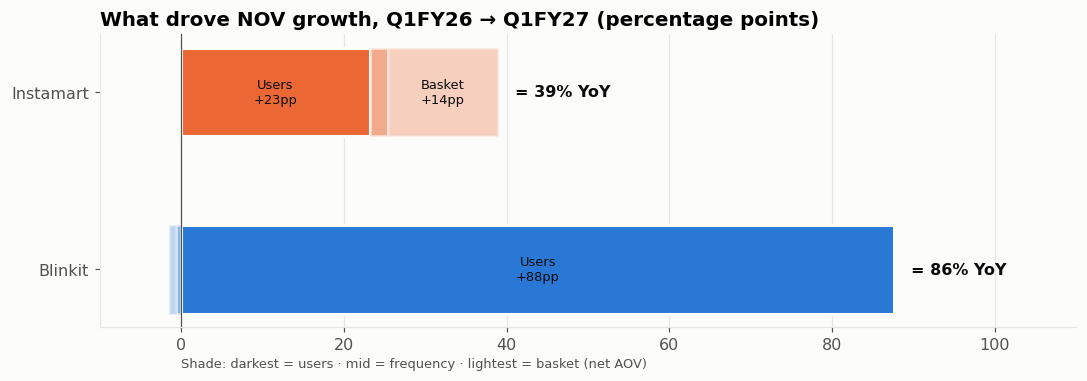

,Users (MTU),Frequency,Basket (Net AOV),Total NOV growth
Blinkit,87.6,-0.6,-0.9,86.2
Instamart,23.2,2.2,13.6,39.0


In [7]:
def decompose(d, q0, q1):
    parts = {"Users (MTU)": np.log(d.mtu_mn[q1]/d.mtu_mn[q0]),
             "Frequency":   np.log(d.freq_per_month[q1]/d.freq_per_month[q0]),
             "Basket (Net AOV)": np.log(d.naov_inr[q1]/d.naov_inr[q0])}
    tot = np.log(d.nov_cr[q1]/d.nov_cr[q0])
    return pd.Series({k: v/tot*(np.exp(tot)-1)*100 for k, v in parts.items()}), (np.exp(tot)-1)*100

rows = {}
for name, d in [("Blinkit", B), ("Instamart", I)]:
    s, total = decompose(d, "Q1FY26", "Q1FY27"); s["Total NOV growth"] = total; rows[name] = s
dec = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(10, 3.6))
drivers = ["Users (MTU)", "Frequency", "Basket (Net AOV)"]
shades = {"Users (MTU)": 1.0, "Frequency": 0.55, "Basket (Net AOV)": 0.3}
for r, p in enumerate(dec.index):
    left_pos, left_neg = 0, 0
    for k in drivers:
        v = dec.loc[p, k]
        start = left_pos if v >= 0 else left_neg + v
        ax.barh(r, v, left=left_pos if v >= 0 else left_neg, color=COL[p], alpha=shades[k], height=0.5, edgecolor=SURF, linewidth=2)
        if abs(v) > 4: ax.text((left_pos if v>=0 else left_neg) + v/2, r, f"{k.split(' ')[0]}\n{v:+.0f}pp", ha="center", va="center", fontsize=8.5, color=INK)
        if v >= 0: left_pos += v
        else: left_neg += v
    ax.text(left_pos + 2, r, f"= {dec.loc[p,'Total NOV growth']:.0f}% YoY", va="center", fontweight="bold", color=INK)
ax.set_yticks(range(len(dec))); ax.set_yticklabels(dec.index); ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlim(-10, 110); ax.set_title("What drove NOV growth, Q1FY26 → Q1FY27 (percentage points)"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.text(0, -0.55, "Shade: darkest = users · mid = frequency · lightest = basket (net AOV)", fontsize=8.5, color=INK2)
save(fig, "03_growth_decomposition"); plt.show()
dec.round(1)

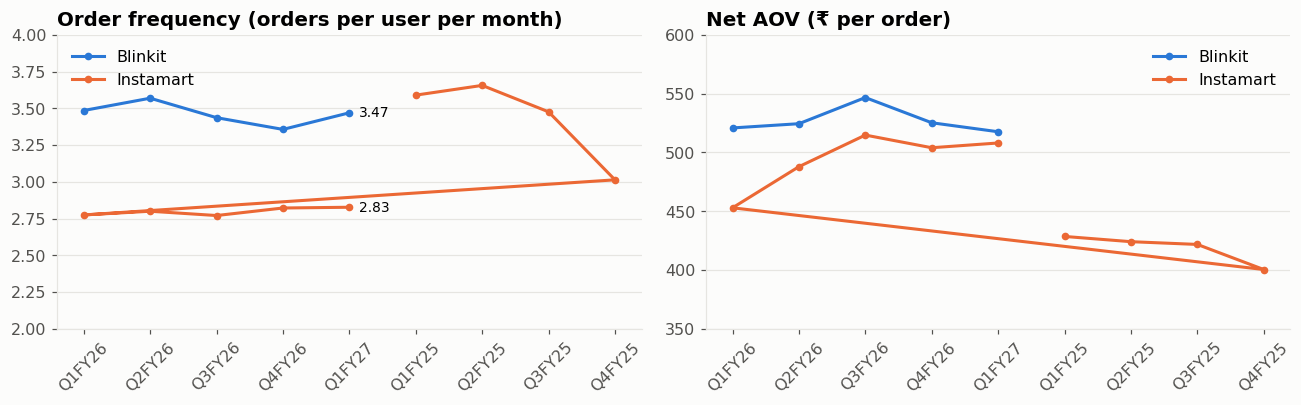

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
for p, d in [("Blinkit", B), ("Instamart", I)]:
    s = d.freq_per_month.dropna(); a1.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=p)
    a1.annotate(f"{s.iloc[-1]:.2f}", (s.index.astype(str)[-1], s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
    s = d.naov_inr.dropna(); a2.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=p)
a1.set_title("Order frequency (orders per user per month)"); a1.set_ylim(2, 4); a1.legend(); a1.tick_params(axis="x", rotation=45)
a2.set_title("Net AOV (₹ per order)"); a2.set_ylim(350, 600); a2.legend(); a2.tick_params(axis="x", rotation=45)
save(fig, "04_frequency_and_basket"); plt.show()

**Read-out.** Blinkit's +86% was **~all new users** (frequency and basket flat). Instamart's +39% was split between users and a **bigger basket** (non-grocery mix, "Maxxsaver" threshold discounts), while frequency sat ~20% below Blinkit's.
Baskets have converged (~₹510–520 each). **Frequency is now the single biggest behavioural gap**, and it feeds straight into store throughput (next section).

## 4. Store productivity & operating leverage: the real gap

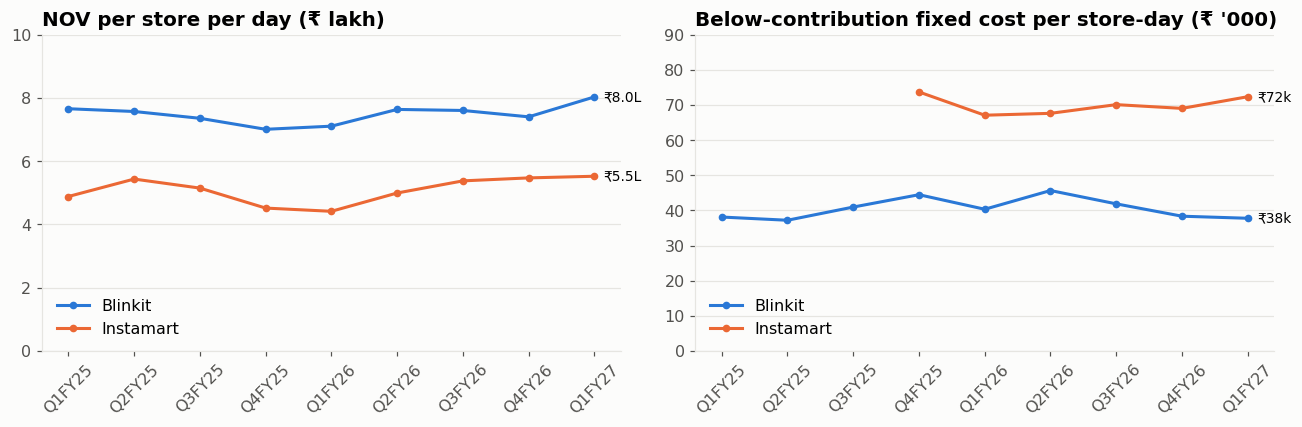

Q1FY27: Blinkit store throughput is 45% higher; Instamart fixed cost/store-day is 1.9x Blinkit's


In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for p, d in [("Blinkit", B), ("Instamart", I)]:
    s = d.nov_store_day_lakh.dropna(); a1.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=p)
    a1.annotate(f"₹{s.iloc[-1]:.1f}L", (s.index.astype(str)[-1], s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
    s = d.fixed_store_day_k.dropna(); a2.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=p)
    a2.annotate(f"₹{s.iloc[-1]:.0f}k", (s.index.astype(str)[-1], s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
a1.set_title("NOV per store per day (₹ lakh)"); a1.set_ylim(0, 10); a1.legend(loc="lower left"); a1.tick_params(axis="x", rotation=45)
a2.set_title("Below-contribution fixed cost per store-day (₹ '000)"); a2.set_ylim(0, 90); a2.legend(loc="lower left"); a2.tick_params(axis="x", rotation=45)
save(fig, "05_store_productivity"); plt.show()
g = B.nov_store_day_lakh["Q1FY27"] / I.nov_store_day_lakh["Q1FY27"] - 1
print(f"Q1FY27: Blinkit store throughput is {g:.0%} higher; Instamart fixed cost/store-day is {I.fixed_store_day_k['Q1FY27']/B.fixed_store_day_k['Q1FY27']:.1f}x Blinkit's")

*"Fixed cost" here = Contribution − Adj. EBITDA: corporate overhead, tech, brand marketing, i.e. everything not tied to an individual order. Spreading it per store-day makes the two networks comparable.*

**Operating leverage view.** Plot every quarter's EBITDA margin against store throughput. The positive slope is operating leverage in action: fixed costs are absorbed as each store does more volume. Blinkit crossed EBITDA break-even once throughput held above ~₹7.5L/day *while* store expansion slowed; its FY25 dip is the **new-store drag** from nearly tripling the network (526 → 1,301 stores).

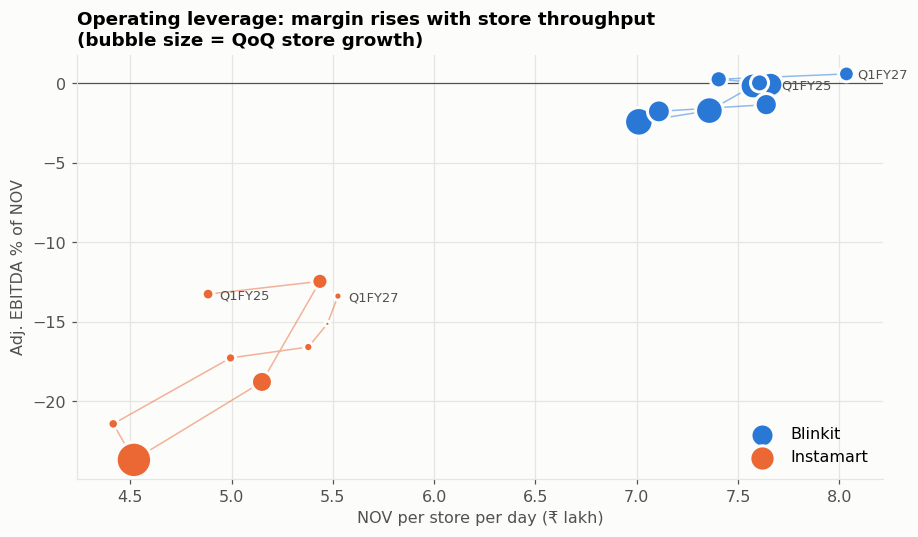

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for p, d in [("Blinkit", B), ("Instamart", I)]:
    s = d.dropna(subset=["nov_store_day_lakh", "ebitda_pct_nov"])
    ax.plot(s.nov_store_day_lakh, s.ebitda_pct_nov, color=COL[p], lw=1, alpha=0.5)
    ax.scatter(s.nov_store_day_lakh, s.ebitda_pct_nov, s=s.store_growth_qoq.clip(lower=1).fillna(5)*12, color=COL[p], edgecolor=SURF, linewidth=2, label=p, zorder=3)
    for q in [s.index[0], s.index[-1]]:
        ax.annotate(str(q), (s.nov_store_day_lakh[q], s.ebitda_pct_nov[q]), xytext=(7, -3), textcoords="offset points", fontsize=8.5, color=INK2)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xlabel("NOV per store per day (₹ lakh)"); ax.set_ylabel("Adj. EBITDA % of NOV")
ax.set_title("Operating leverage: margin rises with store throughput\n(bubble size = QoQ store growth)", fontsize=12)
ax.legend(loc="lower right"); ax.grid(axis="x")
save(fig, "06_operating_leverage"); plt.show()

## 5. Unit economics per order: the P&L of a single delivery

,Blinkit,Instamart
Net AOV,517.6,508.0
Contribution / order,27.4,-1.4
Fixed cost / order,-24.3,-66.6
Adj. EBITDA / order,3.1,-67.9


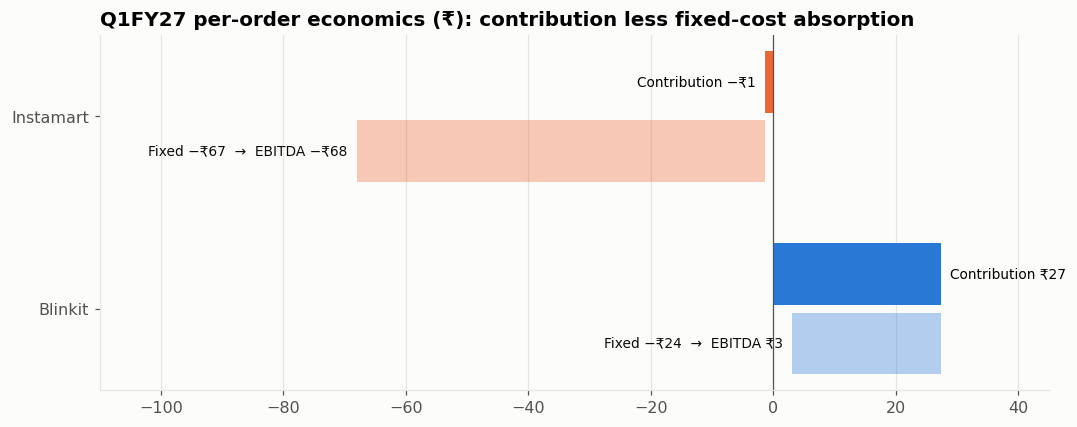

In [11]:
ue = pd.DataFrame({
    p: {"Net AOV": d.naov_inr["Q1FY27"], "Contribution / order": d.cm_per_order["Q1FY27"],
        "Fixed cost / order": -(d.fixed_cr["Q1FY27"] * 1e7 / (d.orders_mn["Q1FY27"] * 1e6)),
        "Adj. EBITDA / order": d.ebitda_per_order["Q1FY27"]} for p, d in [("Blinkit", B), ("Instamart", I)]}).round(1)
display(ue)

fig, ax = plt.subplots(figsize=(10, 4))
for r, p in enumerate(["Blinkit", "Instamart"]):
    cm, fx, eb = ue.loc["Contribution / order", p], ue.loc["Fixed cost / order", p], ue.loc["Adj. EBITDA / order", p]
    ax.barh(r + 0.18, cm, color=COL[p], height=0.32); ax.text(cm + (1.5 if cm >= 0 else -1.5), r + 0.18, f"Contribution {rs(cm)}", va="center", ha="left" if cm >= 0 else "right", fontsize=9)
    ax.barh(r - 0.18, fx, left=cm, color=COL[p], alpha=0.35, height=0.32)
    ax.text(cm + fx - 1.5, r - 0.18, f"Fixed {rs(fx)}  →  EBITDA {rs(eb)}", va="center", ha="right", fontsize=9, color=INK)
ax.axvline(0, color=INK2, lw=0.8); ax.set_yticks([0, 1]); ax.set_yticklabels(["Blinkit", "Instamart"])
ax.set_xlim(-110, 45); ax.set_title("Q1FY27 per-order economics (₹): contribution less fixed-cost absorption"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
save(fig, "07_unit_economics"); plt.show()

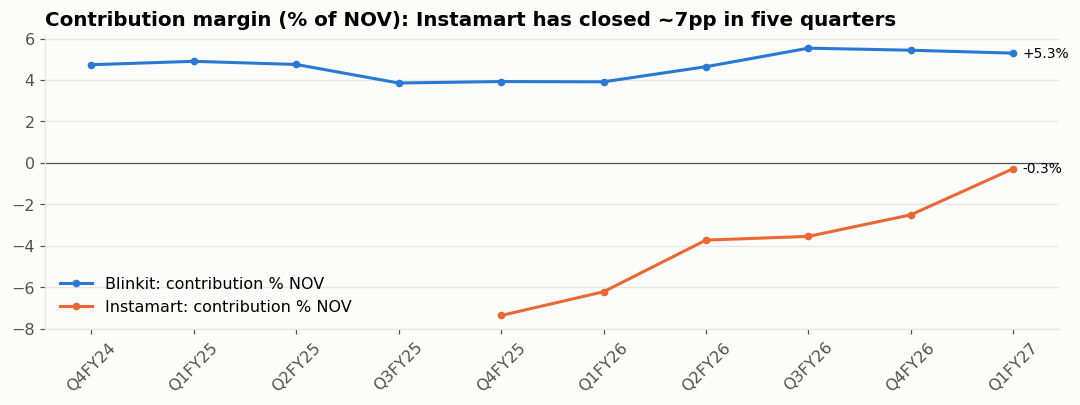

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for p, d in [("Blinkit", B), ("Instamart", I)]:
    s = d.cm_pct_nov.dropna(); ax.plot(s.index.astype(str), s.values, color=COL[p], marker="o", ms=4, label=f"{p}: contribution % NOV")
    ax.annotate(f"{s.iloc[-1]:+.1f}%", (s.index.astype(str)[-1], s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)
ax.axhline(0, color=INK2, lw=0.8); ax.set_title("Contribution margin (% of NOV): Instamart has closed ~7pp in five quarters"); ax.legend(); ax.tick_params(axis="x", rotation=45)
save(fig, "08_contribution_margin"); plt.show()

**Read-out.** Instamart has done the hard *variable-cost* work: contribution per order improved from **−₹30 to ≈ −₹1** in five quarters (fees, ads, bigger baskets, fewer subsidies). But each order still carries **~₹67 of fixed cost vs ~₹24 at Blinkit**. **The remaining problem is scale and density, not pricing.**

## 6. Break-even & scenario model
Simple, transparent model for Instamart's quarterly Adj. EBITDA:

$$\text{EBITDA}_q = \text{NOV}_q \times \text{CM\%}_{\text{NOV}} - \text{Fixed}_q$$

Fixed cost today is ~₹762 Cr/quarter. Fixed costs creep up as the business scales, so I test a range. **Validation:** management guides break-even at *₹60,000 Cr annualised NOV and 5–6% CM (~₹30/order)*. Does my model agree?

In [13]:
fixed_now = I.fixed_cr["Q1FY27"]
cm_target = G["Instamart", "breakeven_cm_pct"] / 100
for fixed_growth in [0.0, 0.08, 0.15]:
    f = fixed_now * (1 + fixed_growth)
    print(f"Fixed cost +{fixed_growth:>4.0%} (₹{f:,.0f} Cr/qtr) -> break-even annualised NOV at {cm_target:.1%} CM = ₹{f / cm_target * 4:,.0f} Cr")
print(f"\nManagement guidance: ₹{G['Instamart','breakeven_nov_runrate_cr']:,.0f} Cr  |  Today's run-rate: ₹{I.nov_cr['Q1FY27']*4:,.0f} Cr "
      f"(needs {G['Instamart','breakeven_nov_runrate_cr']/(I.nov_cr['Q1FY27']*4):.1f}x)")

Fixed cost +  0% (₹762 Cr/qtr) -> break-even annualised NOV at 5.5% CM = ₹55,418 Cr
Fixed cost +  8% (₹823 Cr/qtr) -> break-even annualised NOV at 5.5% CM = ₹59,852 Cr
Fixed cost + 15% (₹876 Cr/qtr) -> break-even annualised NOV at 5.5% CM = ₹63,731 Cr

Management guidance: ₹60,000 Cr  |  Today's run-rate: ₹23,268 Cr (needs 2.6x)


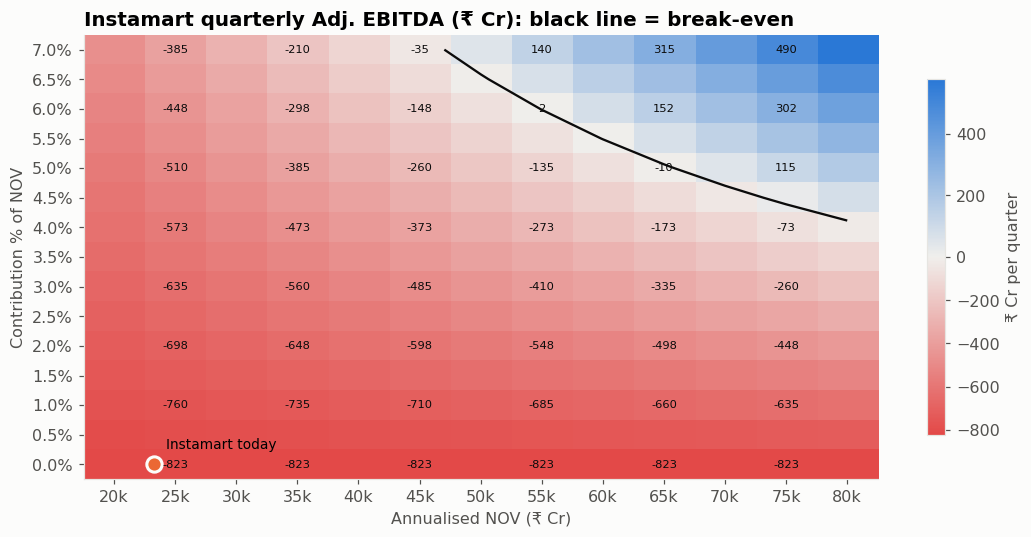

In [14]:
cm_grid = np.arange(0, 7.5, 0.5)                   # contribution % of NOV
nov_grid = np.arange(20_000, 85_000, 5_000)        # annualised NOV, ₹ Cr
fixed_q = fixed_now * 1.08                          # base case: fixed costs +8%
Z = np.array([[n/4 * c/100 - fixed_q for n in nov_grid] for c in cm_grid])  # quarterly EBITDA ₹ Cr

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(Z, cmap=cmap, norm=TwoSlopeNorm(0, Z.min(), Z.max()), aspect="auto", origin="lower")
ax.set_xticks(range(len(nov_grid))); ax.set_xticklabels([f"{n/1000:.0f}k" for n in nov_grid])
ax.set_yticks(range(len(cm_grid))); ax.set_yticklabels([f"{c:.1f}%" for c in cm_grid])
ax.contour(Z, levels=[0], colors=INK, linewidths=1.5)
for yi in range(0, len(cm_grid), 2):
    for xi in range(1, len(nov_grid), 2):
        ax.text(xi, yi, f"{Z[yi, xi]:,.0f}", ha="center", va="center", fontsize=7.5, color=INK)
today_x = (I.nov_cr["Q1FY27"]*4 - nov_grid[0]) / 5000; ax.plot(today_x, 0, marker="o", ms=10, mfc=COL["Instamart"], mec=SURF, mew=2)
ax.annotate("Instamart today", (today_x, 0), xytext=(8, 10), textcoords="offset points", fontsize=9)
ax.set_xlabel("Annualised NOV (₹ Cr)"); ax.set_ylabel("Contribution % of NOV"); ax.grid(False)
ax.set_title("Instamart quarterly Adj. EBITDA (₹ Cr): black line = break-even")
fig.colorbar(im, ax=ax, shrink=0.8, label="₹ Cr per quarter")
save(fig, "09_breakeven_heatmap"); plt.show()

In [15]:
# What does ₹60k Cr NOV mean in operational terms?
target_q = G["Instamart","breakeven_nov_runrate_cr"] / 4
orders_needed = target_q * 1e7 / I.naov_inr["Q1FY27"] / 1e6
mtu_needed = orders_needed / (I.freq_per_month["Q1FY27"] * 3)
mtu_needed_blinkit_freq = orders_needed / (B.freq_per_month["Q1FY27"] * 3)
print(f"Orders/quarter needed: {orders_needed:,.0f} mn (today {I.orders_mn['Q1FY27']:.0f} mn)")
print(f"MTU needed at Instamart's frequency ({I.freq_per_month['Q1FY27']:.2f}): {mtu_needed:.1f} mn  (Blinkit today: {B.mtu_mn['Q1FY27']} mn)")
print(f"MTU needed at Blinkit's frequency   ({B.freq_per_month['Q1FY27']:.2f}): {mtu_needed_blinkit_freq:.1f} mn  -> frequency alone saves {mtu_needed-mtu_needed_blinkit_freq:.1f} mn users")

# Densification lever: value of +₹1 lakh NOV per store per day on today's network
stores = I.stores_end["Q1FY27"]
add_nov = 1e5 * 365 * stores / 1e7
print(f"\n+₹1 lakh NOV/store/day x {stores:,} stores = +₹{add_nov:,.0f} Cr annualised NOV; "
      f"at a {cm_target:.1%} incremental CM that is +₹{add_nov*cm_target:,.0f} Cr/yr EBITDA with ~no new fixed cost")

Orders/quarter needed: 295 mn (today 114 mn)
MTU needed at Instamart's frequency (2.83): 34.8 mn  (Blinkit today: 31.8 mn)
MTU needed at Blinkit's frequency   (3.47): 28.4 mn  -> frequency alone saves 6.4 mn users

+₹1 lakh NOV/store/day x 1,171 stores = +₹4,274 Cr annualised NOV; at a 5.5% incremental CM that is +₹235 Cr/yr EBITDA with ~no new fixed cost


**Read-out.** My bottom-up model lands at **₹55–64k Cr** depending on fixed-cost creep, bracketing management's ₹60k Cr guidance. Operationally that's ~2.6× today's orders, about **35M monthly users at today's frequency**, i.e. *Blinkit's current size*. But if Instamart could lift frequency to Blinkit's level, it would need **~6M fewer users** to get there. That's why frequency is the lever to prioritise.

## 7. Experiment design: testing a frequency lever before scaling it
Leadership shouldn't roll out a frequency program on faith. Here's the A/B test I'd propose.

| | |
|---|---|
| **Hypothesis** | A "come back this week" nudge (a free-delivery pass on the 2nd order within 7 days) raises frequency more than it costs in subsidy |
| **Unit of randomisation** | User (not order), to avoid contamination; stratified by city tier and tenure |
| **Primary metric** | Contribution **per user** over 28 days (captures frequency × margin in one number) |
| **Secondary** | Orders per user per month; D28 retention |
| **Guardrails** | Contribution per order (subsidy leakage), delivery SLA, cancellation rate, NPS |
| **Analysis** | Difference in means with CUPED (pre-period contribution as covariate); per-user metric so no ratio/delta-method issue |
| **Decision rule** | Ship if primary is significantly positive and no guardrail degrades beyond a pre-registered threshold |

**How big must the test be?** Illustrative power analysis. Standard deviations are *my assumptions* (right-skewed spend distributions typically have CV ≈ 1.0–1.5); in a real team I'd pull the historical variance first.

In [16]:
from statsmodels.stats.power import NormalIndPower
pw = NormalIndPower()
monthly_orders = I.freq_per_month["Q1FY27"]
cm_user = 30 * monthly_orders            # ₹ contribution per user-month at the ~₹30/order steady-state target
rows = []
for cv in [1.0, 1.5]:
    for mde in [0.02, 0.03, 0.05]:
        for cuped in [0, 0.4]:            # CUPED with pre-period r^2 = 0.4 cuts variance by 40%
            sd = cm_user * cv * np.sqrt(1 - cuped)
            n = pw.solve_power(effect_size=mde * cm_user / sd, alpha=0.05, power=0.8, alternative="two-sided")
            rows.append({"CV of metric": cv, "MDE": f"{mde:.0%}", "CUPED": "yes" if cuped else "no", "users per arm": int(np.ceil(n))})
power = pd.DataFrame(rows).pivot_table(index=["CV of metric", "MDE"], columns="CUPED", values="users per arm")
power.style.format("{:,.0f}")

**Takeaway:** detecting a 3% lift needs ~10–24k users per arm with CUPED, which is trivially available on a 13.5M-MTU base, so a **2-week test in 2–3 cities** is enough. The real risk isn't sample size; it's **novelty effects**, so I'd hold out a long-running 5% control to read the 8-week effect.

## 8. Is Blinkit's store build-out worth it? Replicating its ROCE framework
Eternal's Q1FY27 letter gives steady-state assumptions: **capex ₹2.5 Cr/store, NOV ₹11 lakh/store/day, NWC 12 days, EBIT 4% of NOV → pre-tax ROCE ≈ 41.7%.** I rebuild it and stress-test each input ±20% (tornado chart), plus the ROCE at *today's* throughput.

Base-case ROCE: 42.0%   (Eternal states 41.7%)
At TODAY's throughput (₹8.27L/day) and 4% EBIT: 34.6%


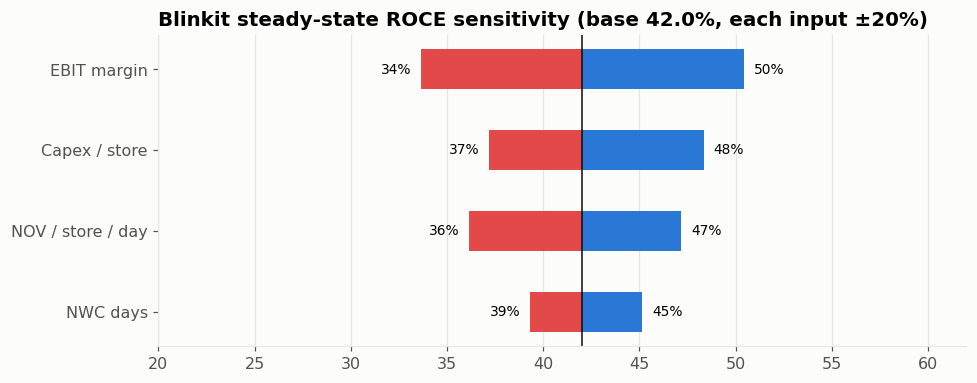

,-20%,+20%,swing
NWC days,45.2,39.3,5.8
NOV / store / day,36.1,47.2,11.1
Capex / store,48.4,37.2,11.2
EBIT margin,33.6,50.5,16.8


In [17]:
def roce(capex=2.5, nov_day_lakh=11, nwc_days=12, ebit=4.0):
    annual_nov_cr = nov_day_lakh * 1e5 * 365 / 1e7
    capital_pct = capex / annual_nov_cr * 100 + nwc_days / 365 * 100
    return ebit / capital_pct * 100

base = roce()
print(f"Base-case ROCE: {base:.1f}%   (Eternal states 41.7%)")
print(f"At TODAY's throughput (₹{B.nov_per_store_day_k['Q1FY27']/100:.2f}L/day) and 4% EBIT: {roce(nov_day_lakh=B.nov_per_store_day_k['Q1FY27']/100):.1f}%")

inputs = {"NOV / store / day": ("nov_day_lakh", 11), "EBIT margin": ("ebit", 4.0), "Capex / store": ("capex", 2.5), "NWC days": ("nwc_days", 12)}
tor = pd.DataFrame({k: {"-20%": roce(**{a: v*0.8}), "+20%": roce(**{a: v*1.2})} for k, (a, v) in inputs.items()}).T
tor["swing"] = (tor["+20%"] - tor["-20%"]).abs(); tor = tor.sort_values("swing")
fig, ax = plt.subplots(figsize=(9, 3.6))
for y, (k, r) in enumerate(tor.iterrows()):
    lo, hi = sorted([r["-20%"], r["+20%"]])
    ax.barh(y, hi - base, left=base, color=COL["Blinkit"], height=0.5); ax.barh(y, lo - base, left=base, color="#e34948", height=0.5)
    ax.text(hi + 0.5, y, f"{hi:.0f}%", va="center", fontsize=9); ax.text(lo - 0.5, y, f"{lo:.0f}%", va="center", ha="right", fontsize=9)
ax.axvline(base, color=INK, lw=1); ax.set_yticks(range(len(tor))); ax.set_yticklabels(tor.index)
ax.set_xlim(20, 62); ax.set_title(f"Blinkit steady-state ROCE sensitivity (base {base:.1f}%, each input ±20%)"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
save(fig, "10_roce_tornado"); plt.show()
tor.round(1)

**Read-out.** ROCE is most sensitive to **EBIT margin**; store throughput and capex per store matter about equally, and working capital barely moves it. (My base case computes 42.0% vs Eternal's stated 41.7%; the gap is Eternal rounding capex to 6.3% of NOV.) Even at today's ₹8.3L/day it would clear ~35% *if* the 4% EBIT margin materialises; margin delivery, not store cost, is the thing to watch. The same logic says Instamart should **fill existing stores before building new ones**.

## 9. Recommendations for Instamart leadership

| # | Recommendation | Why (evidence above) | Size of prize (est.) | Metric to track |
|---|---|---|---|---|
| 1 | **Densify before you expand.** Cap new stores to high-demand micro-markets; push utilisation up from ~40% | Fixed cost/store-day is ~1.9× Blinkit's; margin rises with throughput (§4) | +₹1L NOV/store/day ≈ +₹4,300 Cr annual NOV, ~+₹235 Cr EBITDA at no new fixed cost | NOV/store/day, % stores CM-positive |
| 2 | **Make frequency the North Star for growth teams.** Run the §7 experiment, then scale winners | Frequency 2.8 vs 3.5; closing it cuts users needed for break-even by ~6M (§6) | Each +0.1 orders/user/month ≈ +₹820 Cr annual NOV | Orders/MTU/month, D28 retention |
| 3 | **Accelerate ads + inventory-led model (IOCC)** | Guided +₹10/order (ads) and +₹4–5/order (1P); Blinkit's 1P shift coincided with its margin inflection (§5) | ~₹15/order ≈ ₹690 Cr/yr at today's volume | Ad revenue % NOV, gross margin |
| 4 | **Don't chase Blinkit on store count.** | Zepto's FY26 shows the cost of expansion-led growth: −₹79/order (§2) | Avoided losses | Cash burn per incremental order |

*Size estimates use Q1FY27 run-rates and a 5.5% incremental contribution margin; they are directional and rounded.*

## 10. Limitations & what I'd do with internal data
- **Definitions aren't identical.** Blinkit orders include cancellations; Instamart's CM is reported as % of GOV (I restated to % of NOV); Zepto reports NRV and annual figures only.
- **Derived figures** (Instamart GOV/NOV for some quarters, Zepto orders) are flagged in `data/*.csv`.
- **Blinkit's model changed in Q2FY26** (marketplace → inventory-led), so revenue is not comparable across that break; I rely on NOV, contribution and EBITDA, which are.
- **Fixed cost = Contribution − Adj. EBITDA** bundles marketing with overhead; with internal data I'd split brand vs performance marketing and build store-level cohort curves (maturity ramp by store vintage).
- **Correlation ≠ causation** in §4. The throughput-margin link is supported by the cost structure but not causally identified; with store-level data I'd use a store-vintage panel with fixed effects.

---
### Headline-number tests
Every number in the executive summary is recomputed here, so if the data changes the notebook fails loudly instead of silently shipping stale claims.

In [18]:
assert round(share_pct.Blinkit["Q1FY25"]) == 63 and round(share_pct.Blinkit["Q1FY27"]) == 75
assert round(B.nov_cr["Q1FY27"]/B.nov_cr["Q1FY25"], 1) == 4.2 and round(I.nov_cr["Q1FY27"]/I.nov_cr["Q1FY25"], 1) == 2.4
assert round(B.nov_store_day_lakh["Q1FY27"], 1) == 8.0 and round(I.nov_store_day_lakh["Q1FY27"], 1) == 5.5
assert 70 <= I.fixed_store_day_k["Q1FY27"] <= 74 and 36 <= B.fixed_store_day_k["Q1FY27"] <= 40
assert round(B.freq_per_month["Q1FY27"], 1) == 3.5 and round(I.freq_per_month["Q1FY25"], 1) == 3.6 and round(I.freq_per_month["Q1FY27"], 1) == 2.8
assert round(B.mtu_mn["Q1FY27"]/B.mtu_mn["Q1FY26"]-1, 2) == 0.88
assert round(agg.loc["Zepto","ebitda_per_order_inr"]) == -79 and round(agg.loc["Instamart","ebitda_per_order_inr"]) == -85 and round(agg.loc["Blinkit","ebitda_per_order_inr"]) == -3
assert round(G["Instamart","breakeven_nov_runrate_cr"]/(I.nov_cr["Q1FY27"]*4), 1) == 2.6
assert round(add_nov, -2) == 4300 and round(add_nov*cm_target, -1) in (230, 240)
assert round(0.1*3*4*I.mtu_mn["Q1FY27"]*1e6*I.naov_inr["Q1FY27"]/1e7, -1) == 820
assert round(zq.orders_mn.loc["Q1FY26":"Q4FY26"].sum()) == 640 and round(zq.adj_ebitda_per_order_inr["Q4FY26"]) == -59
print("All headline numbers verified ✔")

All headline numbers verified ✔
